## **Assignment: "The Visual Inspector" — CNN Fundamentals**

**The Scenario**

You have just joined "VisionCore AI" as a Computer Vision Engineer. Your manager hands you a grayscale image classification pipeline that uses a plain MLP — it treats each image as a flat vector and ignores all spatial structure. Your task is to understand *why* CNNs were invented, how their core operations work, and implement the key building blocks from scratch to prove you are ready to rebuild the pipeline the right way.

## **Part 1: Conceptual Questions**

### **Question 1: Why Not Just Use an MLP?**

Your manager asks why the old MLP pipeline struggles with images. Which answer *best* explains the core problem?

A) MLPs cannot use ReLU activations on image data.

B) MLPs flatten the image into a vector, destroying spatial relationships — a pixel and its neighbour are treated no differently from two pixels at opposite corners.

C) MLPs can only process square images.

D) MLPs always overfit because they have too few parameters for image data.

#### Answer : B) MLPs flatten the image into a vector, destroying spatial relationships — a pixel and its neighbour are treated no differently from two pixels at opposite corners.

MLPs require flattening images into 1D vectors. It destroys the 2D spatial structure and local pixel correlations that CNNs are desgined to preserve.

### **Question 2: Parameter Sharing**

A convolutional layer uses a single 3×3 filter (kernel) and slides it across a 28×28 grayscale image. How many *learnable parameters* does this filter have, and why is this beneficial compared to a fully-connected layer of the same output size?

A) 784 parameters; same as the MLP — no difference.

B) 9 parameters; the same filter detects the same feature (e.g. an edge) everywhere in the image, drastically reducing parameter count and enabling translational equivariance.

C) 9 parameters; but this means the network can only detect 9 different features total.

D) 28 parameters; one per row of the image.

#### Answer : B) 9 parameters; the same filter detects the same feature (e.g. an edge) everywhere in the image, drastically reducing parameter count and enabling translational equivariance.

A 3 X 3 filter has 9 parameters that are reused across the entire image. This signficantly reduces the model size compared to dense layer. This also allows network to detect the same feature.

### **Question 3: The Role of Pooling**

After the convolution + ReLU step, you apply 2×2 Max Pooling with stride 2. What are the *two* main effects of this operation?

A) It adds learnable parameters to help the network generalise, and it doubles the spatial resolution.

B) It reduces spatial dimensions (downsampling), and it introduces a degree of translation invariance by retaining only the strongest activation in each region.

C) It normalises pixel values to [0, 1], and it prevents vanishing gradients.

D) It replaces the need for a non-linear activation function.

#### Answer : B) It reduces spatial dimensions (downsampling), and it introduces a degree of translation invariance by retaining only the strongest activation in each region.

Max pooling is downsampling by selecting the maximum value in each 2 X 2 (here) window, which reduces the spatial dimensions and computational load, and this process also provides a degree of translation invariance, as network become less sensitive to extact positions of features.


## **Part 2: Numerical Reasoning**

### **Question 4: Output Size Calculation**

You are given the following CNN layer configuration:

| Setting | Value |
|---|---|
| Input size | 32 × 32 (single channel) |
| Conv layer | 16 filters, kernel 5×5, stride 1, padding 0 |
| Pooling | 2×2 Max Pool, stride 2 |

Using the formula $O = \lfloor\frac{I - K + 2P}{S}\rfloor + 1$:

1. What is the spatial size of the **feature map after the Conv layer**?
2. What is the spatial size **after Max Pooling**?
3. If you then flatten and feed into a fully-connected layer with 10 outputs, how many weights does *that* FC layer have?

1. After  Conv: $O_{conv} = \lfloor \frac{32 - 5 + 2(0)}{1} \rfloor + 1 = 28 \text{ (Spatial size: } 28 \times 28 \text{)}$

2. After  Pooling:  $O_{pool} = \lfloor \frac{28 - 2 + 2(0)}{2} \rfloor + 1 = 14 \text{ (Spatial size: } 14 \times 14 \text{)}$

3. FC  weights: Flattened  volume  = 14 $\times 14 \times 16 \text{ filters} = 3136 \text{ input nodes}$

Total FC weights = 3136 $\text{ inputs} \times 10 \text{ outputs} = 31360 \text{ weights (excluding biases)}$


## **Part 3: Coding Challenge — Build the Core Operations**

In this section you will implement 2D convolution and max pooling from scratch using only NumPy. This mirrors exactly what frameworks like PyTorch do under the hood.

**Fill in the missing lines marked `## FILL IN`.**

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# --- A simple 8x8 synthetic 'image' ---
np.random.seed(42)

image = np.array([
    [0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 1, 1, 1, 0, 0],
    [0, 0, 1, 0, 0, 1, 0, 0],
    [0, 0, 1, 0, 0, 1, 0, 0],
    [0, 0, 1, 1, 1, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0],
], dtype=float)

# --- Edge-detection kernel (vertical Sobel) ---
kernel = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1],
], dtype=float)

print("Image  shape:", image.shape)
print("Kernel shape:", kernel.shape)

Image  shape: (8, 8)
Kernel shape: (3, 3)


In [7]:
import numpy as np

def conv2d(image, kernel, stride=1, padding=0):
    """
    Perform a 2D convolution (no bias, single channel).
    Returns the feature map.
    """
    H, W = image.shape
    K = kernel.shape[0]  # square kernel assumed

    # Step 1: Pad the image with zeros if padding > 0
    if padding > 0:
        image = np.pad(image, padding, mode='constant')

    # Step 2: Calculate output size using the formula from Q4
    # FIXED: Wrapped the calculations in int() so they can be used in range()
    out_H = int(np.floor((H + 2*padding - K) / stride) + 1)
    out_W = int(np.floor((W + 2*padding - K) / stride) + 1)

    feature_map = np.zeros((out_H, out_W))

    # Step 3: Slide the kernel across the image
    for i in range(out_H):
        for j in range(out_W):
            # Extract the patch of the image the kernel sits on
            patch = image[i*stride : i*stride + K,
                          j*stride : j*stride + K]
            
            ## FILL IN: compute the convolution at position (i, j)
            ## Hint: element-wise multiply patch and kernel, then sum
            feature_map[i, j] = np.sum(patch * kernel)

    return feature_map


def relu(x):
    ## FILL IN: apply ReLU (clip negatives to 0)
    x = np.maximum(0, x)
    
    # FIXED: Actually return the variable
    return x 


# --- Example Run to test it ---
# Creating dummy data to test the shapes from your previous image (32x32 input, 5x5 kernel)
image = np.random.rand(32, 32)
kernel = np.random.rand(5, 5)

fmap = conv2d(image, kernel, stride=1, padding=0)
fmap_relu = relu(fmap)

print("Feature map shape:", fmap.shape)

Feature map shape: (28, 28)


In [8]:
def max_pool2d(feature_map, pool_size=2, stride=2):
    """
    Perform 2D Max Pooling.
    """
    H, W = feature_map.shape
    out_H = (H - pool_size) // stride + 1
    out_W = (W - pool_size) // stride + 1
    pooled = np.zeros((out_H, out_W))

    for i in range(out_H):
        for j in range(out_W):
            patch = feature_map[i*stride : i*stride + pool_size,
                                j*stride : j*stride + pool_size]
            ## FILL IN: take the maximum value in the patch
            pooled[i, j] =  np.max(patch)

    return pooled


# --- Run Max Pooling ---
pooled = max_pool2d(fmap_relu, pool_size=2, stride=2)
print("Pooled feature map shape:", pooled.shape)

Pooled feature map shape: (14, 14)


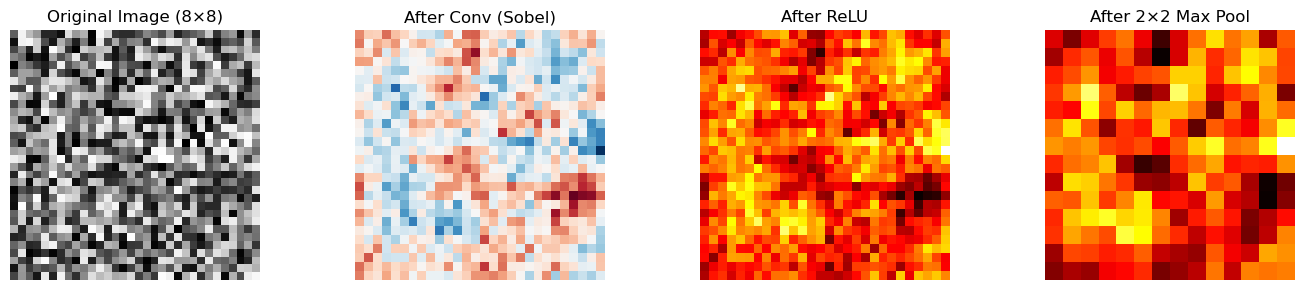

In [9]:
# --- Visualise the pipeline ---
fig, axes = plt.subplots(1, 4, figsize=(14, 3))

axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original Image (8×8)')

axes[1].imshow(fmap, cmap='RdBu')
axes[1].set_title('After Conv (Sobel)')

axes[2].imshow(fmap_relu, cmap='hot')
axes[2].set_title('After ReLU')

axes[3].imshow(pooled, cmap='hot')
axes[3].set_title('After 2×2 Max Pool')

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

### **Observations**

> Answer the following after running your code:
>
> 1. What does the feature map *after Conv* tell you about the image? Where are the high-magnitude responses, and why?
> 2. What does ReLU remove, and why is that useful here?
> 3. The pooled map is much smaller — does it still capture the essential structure of the original image? What is lost?

...


1. The convolution step acts as an edge detector which finds boundaries and outlines in the original image. High magnitude responses are happening exactly where there is a sharp, sudden contrast between light and dark pixels.

2. The ReLU step removes all negative numbers from the map by turning them to zero. This is useful because it isolates just the positive edge features and helps the network learn complex patterns.

3. Max pooling shrinks the map but keeps the essential structure by saving only the strongest, brightest signals. You lose the exact pixel locations, but this actually helps the AI recognize features even if they shift around slightly.